# Chapter 1 - Getting Started with Time Series

## Mục tiêu chương
Chương này giới thiệu các kiến thức nền tảng nhất của chuỗi thời gian, bao gồm:

- Cách đọc và lưu dữ liệu time series
- Phân biệt dữ liệu univariate và multivariate
- Nhận diện các thành phần cơ bản của chuỗi thời gian như trend và seasonality
- Thực hiện decomposition để tách chuỗi thành các thành phần riêng biệt
- Trực quan hóa seasonality để hiểu đặc trưng dữ liệu

## Ý nghĩa
Đây là chương nền tảng để chuẩn bị cho các mô hình dự báo ở Chapter 2.  
Nếu chưa hiểu rõ cách dữ liệu time series được tổ chức và các pattern bên trong nó, thì rất khó áp dụng chính xác các mô hình thống kê hoặc machine learning về sau.

---

## Dataset sử dụng
- GDP (US)
- Retail Turnover
- Air Passengers
- Shampoo Sales
- Beijing Pollution Dataset
- Daily Min Temperatures

## Recipe 1-1A - Reading Time Series Objects (Air Passengers)

### Bài toán

Mục tiêu của phần này là đọc dữ liệu chuỗi thời gian từ file CSV và đưa vào `pandas DataFrame`, trong đó cột thời gian được chuyển sang đúng kiểu `datetime` và được đặt làm chỉ mục thời gian (`index`) để phục vụ cho các bước phân tích sau.

### Dataset

Dataset **Air Passengers** là dữ liệu số lượng hành khách hàng không theo từng tháng.

Đây là một bộ dữ liệu kinh điển trong bài toán chuỗi thời gian vì:
- dữ liệu được ghi nhận theo thứ tự thời gian
- có xu hướng tăng dần theo thời gian
- có tính mùa vụ rõ ràng theo chu kỳ năm

Do đó, bộ dữ liệu này rất phù hợp để minh họa cho các thao tác cơ bản như:
- đọc dữ liệu time series
- trực quan hóa ban đầu
- nhận diện xu hướng và mùa vụ

### Ý tưởng chính

Khi làm việc với dữ liệu chuỗi thời gian, cột thời gian cần được:
1. chuyển sang kiểu `datetime`
2. đặt làm `index` của DataFrame

Điều này giúp việc:
- trực quan hóa dữ liệu theo thời gian
- resampling
- rolling statistics
- decomposition
- forecasting

trở nên thuận tiện và đúng bản chất của bài toán time series.

### Bước 1A-1. Import các thư viện cần thiết.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

### Phân tích code

- `pandas` được sử dụng để đọc và xử lý dữ liệu bảng.
- `matplotlib.pyplot` được sử dụng để trực quan hóa dữ liệu.
- Đây là hai thư viện cơ bản và phổ biến nhất trong các bài toán phân tích dữ liệu chuỗi thời gian ở mức nhập môn.

### Bước 1A-2. Xử lý việc parse cột thời gian theo phiên bản pandas mới

Trong tài liệu gốc, tác giả sử dụng một hàm `date_parser_fn` để chỉ rõ cách chuyển chuỗi ngày tháng sang kiểu `datetime`.

Ví dụ trong phiên bản cũ:

```python
from datetime import datetime
date_parser_fn = lambda dates: datetime.strptime(dates, '%Y-%m')
```
Tuy nhiên, từ pandas 2.0 trở lên, tham số date_parser trong pd.read_csv() đã bị loại bỏ. Vì vậy, trong phiên bản hiện tại, ta không còn truyền date_parser vào read_csv() nữa.

Thay vào đó, ta để pandas tự động parse cột thời gian thông qua tham số parse_dates.

### Phân tích và liên hệ lý thuyết

Trong bài toán chuỗi thời gian, việc xử lý đúng cột thời gian là bước rất quan trọng vì trục thời gian chính là nền tảng để phân tích dữ liệu.

Ở phiên bản cũ của pandas:
- người dùng có thể tự định nghĩa hàm parsing để kiểm soát định dạng ngày tháng

Ở phiên bản mới:
- `pandas` đã đơn giản hóa quá trình này
- chỉ cần chỉ rõ cột cần parse bằng `parse_dates`
- dữ liệu vẫn được chuyển sang `datetime` để sử dụng cho các bước phân tích tiếp theo

Điều này cho thấy:
- bản chất xử lý dữ liệu không thay đổi
- chỉ có cách viết code được cập nhật theo API mới của thư viện

### Bước 1A-3. Đọc dữ liệu

In [61]:
data = pd.read_csv(
    "./data/AirPassengers.csv",
    parse_dates=["Month"],
    index_col="Month"
)

data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### Phân tích code

- `pd.read_csv()` dùng để đọc dữ liệu từ file CSV.
- `parse_dates=["Month"]` yêu cầu pandas tự động chuyển cột `Month` sang kiểu dữ liệu thời gian (`datetime64`).
- `index_col="Month"` đặt cột `Month` làm chỉ mục của DataFrame.

Việc đặt cột thời gian làm `index` là thực hành rất quan trọng trong phân tích chuỗi thời gian vì:
- giúp biểu đồ hiển thị đúng theo trục thời gian
- hỗ trợ tốt cho các thao tác như lọc theo mốc thời gian, resample, rolling, decomposition và forecasting

### Kiểm tra nhanh cấu trúc dữ liệu

In [62]:
print(data.info())
print()
print(data.head())
print()
print(data.index)

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', name='Month', length=144, freq=None)


### Phân tích output

Sau khi đọc dữ liệu, ta cần kiểm tra nhanh cấu trúc của DataFrame để xác nhận:

- cột thời gian đã được chuyển sang kiểu `datetime`
- cột thời gian đã trở thành `index`
- cột giá trị hành khách là dữ liệu số để có thể dùng cho trực quan hóa và mô hình hóa

Nếu các điều kiện này được đảm bảo, dữ liệu đã ở trạng thái phù hợp để tiếp tục phân tích chuỗi thời gian.

### Bước 1A-4. Trực quan hóa chuỗi thời gian

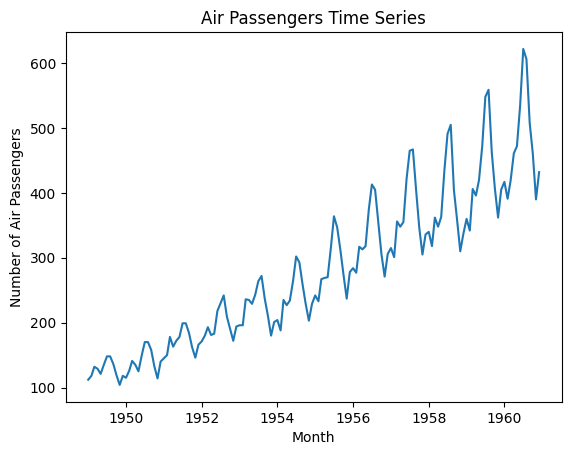

In [63]:
# plt.figure(figsize=(10, 5))
plt.plot(data)
plt.xlabel("Month")
plt.ylabel("Number of Air Passengers")
plt.title("Air Passengers Time Series")
plt.show()

In [64]:
with open('./data/AirPassengers.obj', 'wb') as fp:
    pickle.dump(data, fp)

with open('./data/AirPassengers.obj', 'rb') as fp:
    data = pickle.load(fp)

data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### Phân tích code

- `plt.figure(figsize=(10, 5))` tạo khung hình với kích thước phù hợp để biểu đồ dễ quan sát hơn.
- `plt.plot(data)` vẽ đường biểu diễn của chuỗi thời gian.
- `plt.xlabel("Month")` đặt tên cho trục hoành là thời gian theo tháng.
- `plt.ylabel("Number of Air Passengers")` đặt tên cho trục tung là số lượng hành khách.
- `plt.title("Air Passengers Time Series")` thêm tiêu đề để làm rõ nội dung biểu đồ.

Biểu đồ đường là cách trực quan hóa cơ bản và phù hợp nhất ở bước đầu khi làm việc với time series, vì nó cho phép quan sát:
- xu hướng chung của dữ liệu
- biến động theo thời gian
- dấu hiệu mùa vụ
- các điểm bất thường nếu có

### Nhận xét biểu đồ

Từ biểu đồ chuỗi thời gian, có thể rút ra một số nhận xét quan trọng:

1. **Xu hướng tăng dần theo thời gian**  
   Số lượng hành khách hàng không nhìn chung tăng dần qua các năm. Điều này cho thấy chuỗi có thành phần **trend** rõ rệt.

2. **Tính mùa vụ rõ ràng**  
   Biểu đồ xuất hiện các đỉnh và đáy lặp lại theo chu kỳ đều đặn giữa các năm. Đây là dấu hiệu điển hình của **seasonality** trong dữ liệu time series.

3. **Biên độ dao động tăng theo thời gian**  
   Về sau, khoảng cách giữa các đỉnh và đáy lớn hơn giai đoạn đầu. Điều này gợi ý rằng chuỗi có thể phù hợp hơn với mô hình mùa vụ nhân (`multiplicative seasonality`) hơn là cộng (`additive seasonality`).

4. **Dữ liệu không dừng (non-stationary)**  
   Vì chuỗi có cả xu hướng tăng và mùa vụ, dữ liệu chưa thỏa mãn tính dừng. Đây là một đặc điểm quan trọng cần lưu ý trước khi xây dựng các mô hình như ARIMA.

### Kết luận

Trong recipe này, ta đã thực hiện thành công các bước cơ bản nhất khi làm việc với dữ liệu chuỗi thời gian:

- đọc dữ liệu từ file CSV
- chuyển cột thời gian sang kiểu `datetime`
- đặt cột thời gian làm `index`
- trực quan hóa dữ liệu bằng biểu đồ đường
- quan sát và nhận diện sơ bộ các đặc trưng như xu hướng và mùa vụ

Kết quả cho thấy bộ dữ liệu Air Passengers là một chuỗi thời gian điển hình với:
- xu hướng tăng dần theo thời gian
- mùa vụ rõ rệt
- biên độ dao động tăng dần

Đây là cơ sở quan trọng cho các bước phân tích time series nâng cao ở các phần tiếp theo.

## Recipe 1-1B. Reading Time Series Objects (US GDP Data)

### Bài toán

Mục tiêu của phần này là đọc dữ liệu GDP theo thời gian, biểu diễn dữ liệu dưới dạng chuỗi thời gian và lưu trữ lại đối tượng dữ liệu để có thể sử dụng ở các bước phân tích sau.

### Điều chỉnh so với tài liệu gốc

Trong tài liệu gốc, tác giả sử dụng bộ dữ liệu **GDPIndia**. Tuy nhiên, trong quá trình thực hành hiện tại, file dữ liệu này không còn sẵn có. Vì vậy, để đảm bảo vẫn giữ đúng mục tiêu học thuật của recipe, phần thực nghiệm được điều chỉnh sang sử dụng bộ dữ liệu **GDPUS**.

Việc thay đổi dataset không làm thay đổi bản chất của bài toán, vì cả hai đều là dữ liệu GDP theo thời gian và đều phù hợp để minh họa cách:
- đọc dữ liệu time series
- tạo chỉ mục thời gian
- trực quan hóa chuỗi
- lưu và nạp lại đối tượng dữ liệu

### Dataset

Dataset được sử dụng ở đây là **GDPUS**, chứa thông tin GDP của Hoa Kỳ theo từng năm.

Dữ liệu này phù hợp với bài toán chuỗi thời gian vì:
- các quan sát được sắp xếp theo thời gian
- mỗi dòng dữ liệu tương ứng với một năm
- giá trị GDP có thể được trực quan hóa và phân tích như một chuỗi thời gian kinh tế

Đây là dạng dữ liệu rất phổ biến trong các bài toán phân tích kinh tế - tài chính.

### Ý tưởng chính

Mục tiêu của recipe này không chỉ dừng ở việc đọc dữ liệu từ file CSV, mà còn nhấn mạnh hai thao tác quan trọng:

1. tạo một cột thời gian chuẩn để biểu diễn chuỗi theo trục thời gian
2. lưu lại đối tượng dữ liệu sau khi xử lý để tái sử dụng mà không cần tiền xử lý lại từ đầu

Điều này rất hữu ích trong thực tế khi làm việc với các pipeline phân tích dữ liệu, đặc biệt khi:
- dữ liệu đã qua xử lý
- cần lưu lại trạng thái hiện tại của DataFrame
- muốn tái sử dụng dữ liệu nhanh chóng trong các notebook hoặc chương trình khác

### Bước 1B-1. Import các thư viện cần thiết.

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

### Phân tích code

- `pandas` được sử dụng để đọc và xử lý dữ liệu bảng.
- `matplotlib.pyplot` được sử dụng để trực quan hóa chuỗi thời gian.
- `pickle` được sử dụng để lưu và nạp lại đối tượng Python, trong trường hợp này là `DataFrame`.

Việc dùng `pickle` cho phép lưu toàn bộ cấu trúc dữ liệu sau khi xử lý mà không cần đọc lại CSV và xử lý lại từ đầu.

### Bước 1B-2: Đọc dữ liệu chuỗi thời gian GDP của Hoa Kỳ
Do không còn file `GDPIndia`, phần này sử dụng file `GDPUS.csv` để minh họa cùng ý tưởng đọc dữ liệu chuỗi thời gian GDP theo năm.

In [66]:
us_gdp_data = pd.read_csv('./data/GDPUS.csv', header=0)
us_gdp_data['TimeIndex'] = pd.to_datetime(us_gdp_data['Year'].astype(str), format='%Y')
us_gdp_data.head(5).T

,0,1,2,3,4
Year,1929,1930,1931,1932,1933
GDP,821.8,748.9,691.3,599.7,587.1
TimeIndex,1929-01-01 00:00:00,1930-01-01 00:00:00,1931-01-01 00:00:00,1932-01-01 00:00:00,1933-01-01 00:00:00


### Phân tích code

- `pd.read_csv('./data/GDPUS.csv', header=0)` đọc dữ liệu từ file CSV, trong đó dòng đầu tiên được xem là tên cột.
- `us_gdp_data['Year'].astype(str)` chuyển cột năm sang chuỗi để chuẩn bị cho quá trình chuyển đổi thời gian.
- `pd.to_datetime(..., format='%Y')` chuyển giá trị năm sang kiểu `datetime`, giúp dữ liệu có thể được xử lý như một chuỗi thời gian thực thụ.
- `us_gdp_data.head(5).T` hiển thị 5 dòng đầu tiên theo dạng chuyển vị để dễ quan sát cấu trúc dữ liệu.

Ở đây, cột `TimeIndex` đóng vai trò là cột thời gian đại diện cho từng quan sát GDP theo năm.

### Vì sao cần tạo `TimeIndex`?

Trong dữ liệu gốc, cột `Year` chỉ là số nguyên biểu diễn năm. Nếu giữ nguyên dạng số, dữ liệu chưa thực sự được xem là chuỗi thời gian đúng nghĩa trong các thao tác phân tích của pandas hoặc matplotlib.

Khi chuyển `Year` sang `datetime`:
- trục thời gian được biểu diễn đúng bản chất
- việc trực quan hóa trở nên tự nhiên hơn
- dữ liệu sẵn sàng cho các thao tác time series nâng cao về sau

Đây là một bước chuẩn hóa rất quan trọng khi làm việc với dữ liệu kinh tế theo năm, quý hoặc tháng.

### Kiểm tra nhanh dữ liệu sau khi đọc

In [67]:
print(us_gdp_data.info())
print()
print(us_gdp_data.head())
print()
print(us_gdp_data.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Year       63 non-null     int64         
 1   GDP        63 non-null     float64       
 2   TimeIndex  63 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.6 KB
None

   Year    GDP  TimeIndex
0  1929  821.8 1929-01-01
1  1930  748.9 1930-01-01
2  1931  691.3 1931-01-01
3  1932  599.7 1932-01-01
4  1933  587.1 1933-01-01

Year                  int64
GDP                 float64
TimeIndex    datetime64[us]
dtype: object


### Phân tích output

Dựa trên kết quả từ `info()` và `head()`, có thể rút ra các đặc điểm quan trọng của dataset:

- Dataset gồm **63 quan sát**, tương ứng với giai đoạn từ năm **1929 đến 1991**
- Có 3 cột:
  - `Year`: kiểu `int64`, biểu diễn năm gốc
  - `GDP`: kiểu `float64`, là biến số chính cần phân tích
  - `TimeIndex`: kiểu `datetime64`, được tạo ra để phục vụ cho phân tích chuỗi thời gian

- Không có giá trị thiếu (`Non-Null Count = 63` cho tất cả các cột)

- Cột `TimeIndex` đã được chuyển sang đúng kiểu `datetime`, cho phép:
  - trực quan hóa theo trục thời gian
  - sử dụng các phương pháp phân tích time series trong pandas và statsmodels

Như vậy, dữ liệu đã ở trạng thái "clean" và sẵn sàng cho các bước phân tích tiếp theo.

### Bước 1B-3: Trực quan hóa biểu đồ chuỗi thời gian

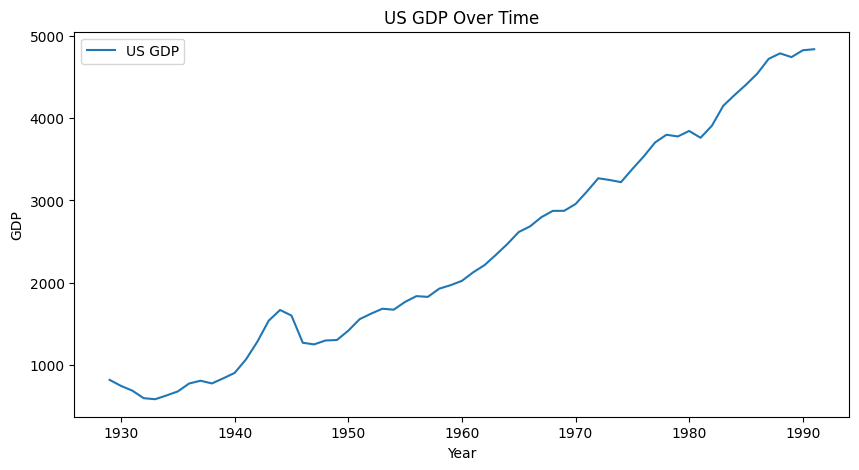

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(us_gdp_data['TimeIndex'], us_gdp_data['GDP'])
plt.legend(['US GDP'], loc='best')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('US GDP Over Time')
plt.show()

### Phân tích code

- `plt.plot(us_gdp_data['TimeIndex'], us_gdp_data['GDP'])` vẽ chuỗi thời gian GDP theo trục năm.
- `plt.legend(['US GDP'], loc='best')` thêm chú giải cho đường biểu diễn.
- `plt.xlabel('Year')` và `plt.ylabel('GDP')` đặt nhãn cho hai trục.
- `plt.title('US GDP Over Time')` thêm tiêu đề cho biểu đồ.

Biểu đồ đường là cách trực quan hóa phù hợp nhất cho dữ liệu time series vì nó cho thấy:
- xu hướng tăng hoặc giảm theo thời gian
- các giai đoạn tăng trưởng nhanh hoặc chậm
- các biến động bất thường nếu có

### Nhận xét biểu đồ

Từ biểu đồ GDP theo thời gian, có thể rút ra một số nhận xét quan trọng:

1. **Xu hướng tăng trưởng dài hạn (Long-term upward trend)**  
   GDP của Hoa Kỳ có xu hướng tăng rõ rệt trong dài hạn, đặc biệt từ sau năm 1950. Điều này phản ánh sự phát triển kinh tế liên tục qua các giai đoạn.

2. **Giai đoạn suy giảm rõ rệt (1930s)**  
   Trong giai đoạn đầu (khoảng 1929–1933), GDP giảm mạnh. Đây là dấu hiệu điển hình của cuộc **Đại suy thoái (Great Depression)**.

3. **Tăng trưởng mạnh sau Thế chiến II**  
   Từ khoảng năm 1945 trở đi, GDP tăng nhanh và ổn định hơn, cho thấy giai đoạn phục hồi và bùng nổ kinh tế.

4. **Không có tính mùa vụ rõ ràng**  
   Vì dữ liệu là theo năm, nên không xuất hiện các chu kỳ lặp lại ngắn hạn như dữ liệu theo tháng hoặc quý.

5. **Chuỗi có xu hướng (trend) nhưng ít nhiễu**  
   So với nhiều time series khác, GDP có biến động tương đối mượt, phù hợp cho các mô hình dự báo xu hướng dài hạn.

6. **Dữ liệu không dừng (non-stationary)**  
   Do có xu hướng tăng rõ ràng, chuỗi không thỏa mãn tính dừng → cần xử lý (ví dụ: differencing) trước khi áp dụng các mô hình như ARIMA.

### Bước 1B-4: Lưu và tải lại dữ liệu dưới dạng pickle

In [69]:
with open('./data/gdp_us.obj', 'wb') as fp:
    pickle.dump(us_gdp_data, fp)

with open('./data/gdp_us.obj', 'rb') as fp:
    us_gdp_data1 = pickle.load(fp)

us_gdp_data1.head()

,Year,GDP,TimeIndex
0,1929,821.8,1929-01-01
1,1930,748.9,1930-01-01
2,1931,691.3,1931-01-01
3,1932,599.7,1932-01-01
4,1933,587.1,1933-01-01


### Phân tích code

- `open('./data/gdp_us.obj', 'wb')` mở file ở chế độ ghi nhị phân.
- `pickle.dump(us_gdp_data, fp)` lưu toàn bộ DataFrame `us_gdp_data` vào file pickle.
- `open('./data/gdp_us.obj', 'rb')` mở lại file ở chế độ đọc nhị phân.
- `pickle.load(fp)` nạp lại đối tượng đã lưu trước đó.
- `us_gdp_data1.head()` dùng để kiểm tra nhanh dữ liệu sau khi được nạp lại.

Điểm quan trọng là:
- dữ liệu sau khi nạp lại vẫn giữ nguyên cấu trúc
- không cần đọc lại từ CSV
- không cần tạo lại cột thời gian từ đầu

### Ý nghĩa của việc lưu dưới dạng pickle

Lưu đối tượng dưới dạng `pickle` có ý nghĩa thực tiễn rất lớn trong các bài toán phân tích dữ liệu:

- tiết kiệm thời gian xử lý lại
- giữ nguyên DataFrame sau các bước làm sạch hoặc biến đổi
- thuận tiện khi làm việc với notebook nhiều bước
- dễ tái sử dụng trong các chương trình Python khác

Tuy nhiên, `pickle` thường phù hợp hơn cho lưu trữ nội bộ trong môi trường Python. Nếu cần chia sẻ dữ liệu giữa nhiều hệ thống hoặc công cụ khác nhau, định dạng CSV vẫn phổ biến hơn.

### Kiểm tra lại dữ liệu sau khi nạp từ pickle

In [70]:
print(us_gdp_data1.info())
print()
print(us_gdp_data1.head())
print()
print(us_gdp_data1.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Year       63 non-null     int64         
 1   GDP        63 non-null     float64       
 2   TimeIndex  63 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.6 KB
None

   Year    GDP  TimeIndex
0  1929  821.8 1929-01-01
1  1930  748.9 1930-01-01
2  1931  691.3 1931-01-01
3  1932  599.7 1932-01-01
4  1933  587.1 1933-01-01

Year                  int64
GDP                 float64
TimeIndex    datetime64[us]
dtype: object


### Phân tích output

Dựa trên kết quả sau khi nạp lại từ file pickle:

- Số lượng quan sát vẫn là **63 dòng**, không thay đổi so với dữ liệu ban đầu
- Các cột `Year`, `GDP`, `TimeIndex` vẫn được giữ nguyên
- Kiểu dữ liệu:
  - `GDP`: float64
  - `TimeIndex`: datetime64
  - `Year`: int64

- Không có giá trị bị mất hoặc thay đổi

Điều này cho thấy:
- `pickle` đã lưu và khôi phục đầy đủ cấu trúc dữ liệu
- toàn bộ quá trình tiền xử lý (tạo `TimeIndex`) được giữ nguyên

Điều này rất quan trọng trong thực tế, vì giúp:
- tránh phải xử lý lại dữ liệu từ đầu
- đảm bảo tính nhất quán giữa các lần chạy mô hình

### Kết luận

Trong recipe này, ta đã thực hiện các bước quan trọng trong việc xử lý dữ liệu chuỗi thời gian:

- đọc dữ liệu GDP từ file CSV
- chuyển đổi cột `Year` thành biến thời gian `TimeIndex`
- trực quan hóa chuỗi GDP theo thời gian
- lưu và nạp lại DataFrame bằng pickle

Qua đó, có thể rút ra hai ý chính:

1. **Chuẩn hóa trục thời gian là bước bắt buộc**  
   Nếu không chuyển dữ liệu sang dạng `datetime`, việc phân tích chuỗi thời gian sẽ không chính xác hoặc không thực hiện được.

2. **Lưu trữ dữ liệu sau xử lý giúp tối ưu pipeline phân tích**  
   Việc sử dụng pickle giúp tiết kiệm thời gian và đảm bảo tính nhất quán khi làm việc với dữ liệu đã qua tiền xử lý.

Recipe này đóng vai trò như một bước nền tảng trước khi áp dụng các kỹ thuật phân tích và dự báo chuỗi thời gian nâng cao.

## Recipe 1-2. Saving Time Series Objects

### Bài toán

Mục tiêu của phần này là lưu một đối tượng chuỗi thời gian (time series DataFrame) đã được nạp và xử lý vào file để có thể tái sử dụng sau này.

### Solution

Sử dụng pandas để lưu DataFrame dưới dạng file CSV.

### How It Works
Các bước dưới đây lưu time series object.

### Bước 2-1: Lưu đối tượng chuỗi thời gian đã được tải trước đó

In [71]:
### Saving the TS object as csv
data.to_csv('./data/ts_data.csv', index=True, sep=',')

### Check the obj stored
data1 = pd.read_csv('./data/ts_data.csv')
data1.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### Phân tích code

- `to_csv()`:
  - dùng để lưu DataFrame ra file CSV
  - `index=True`: lưu cả index (ở đây là cột thời gian)
  - `sep=','`: dùng dấu phẩy làm ký tự phân tách

- `pd.read_csv()`:
  - đọc lại file vừa lưu để kiểm tra dữ liệu

### Phân tích output

Dữ liệu sau khi đọc lại có dạng:

- Cột `Month` (trước là index) đã trở thành một cột bình thường
- Index mới là số thứ tự (0,1,2,...)

Điều này cho thấy:

- Khi lưu CSV, cấu trúc index không được giữ nguyên như DataFrame ban đầu
- Nếu muốn giữ cấu trúc time series, cần parse lại cột thời gian khi đọc lại

### Kết luận

- `to_csv()` là cách đơn giản nhất để lưu dữ liệu
- Tuy nhiên, cần xử lý lại khi đọc để khôi phục cấu trúc time series
- CSV phù hợp để chia sẻ dữ liệu, nhưng không tối ưu để lưu trạng thái phân tích

## Recipe 1-3A. Exploring Types of Time Series Data: Univariate

### Bài toán

Mục tiêu là đọc và khám phá dữ liệu chuỗi thời gian một biến (univariate time series).
### Solution

Univariate time series là chuỗi chỉ có **một biến phụ thuộc theo thời gian**.

Trong dataset này:
- biến duy nhất là nhiệt độ (`Temp`)
- thời gian là biến độc lập
### Dataset

Dataset chứa nhiệt độ tối thiểu hàng ngày tại Southern Hemisphere từ năm 1981 đến 1990.

Đặc điểm:
- dữ liệu theo ngày
- có tính mùa vụ rõ ràng theo năm
- phù hợp để phân tích time series cơ bản


### Bước 3A-1. Import các thư viện cần thiết.
Đã Import ở những cell trước

### Bước 3A-2: Đọc dữ liệu chuỗi thời gian

In [72]:
data = pd.read_csv(
    './data/daily-min-temperatures.csv',
    header=0,
    index_col=0,
    parse_dates=[0]
)

data.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


thêm một đoạn fix chỉnh sửa thế nào so với bản cũ

### Phân tích code

- `index_col=0`: dùng cột Date làm index
- `parse_dates=[0]`: chuyển cột Date sang datetime

Đây là cách chuẩn trong pandas mới (thay cho `parse_dates=True` + `squeeze`)

### Phân tích output

- Dữ liệu có:
  - index: Date (datetime)
  - 1 cột: Temp

Đây chính là **univariate time series**

### Bước 3A-3: Vẽ biểu đồ chuỗi thời gian

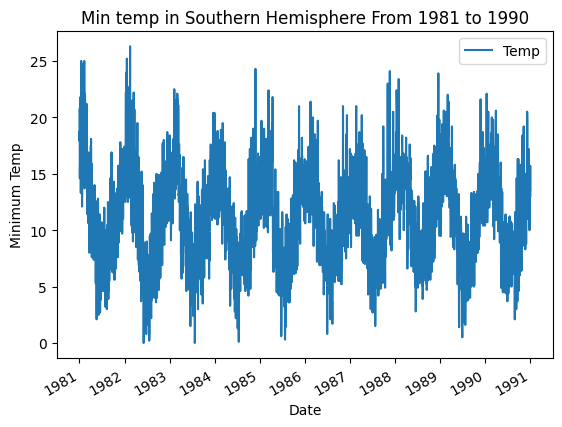

In [73]:
data.plot()
plt.ylabel('Minimum Temp')
plt.title('Min temp in Southern Hemisphere From 1981 to 1990')
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ nhiệt độ theo thời gian, có thể rút ra:

1. **Tính mùa vụ rất rõ ràng (strong seasonality)**  
   Nhiệt độ tăng và giảm theo chu kỳ lặp lại hàng năm.

2. **Không có xu hướng dài hạn rõ rệt**  
   Không giống GDP hay AirPassengers, dữ liệu dao động quanh một mức trung bình.

3. **Biến động ngắn hạn (noise)**  
   Có nhiều dao động nhỏ giữa các ngày → phản ánh yếu tố thời tiết ngẫu nhiên.

4. **Chuỗi gần như stationary**  
   - Không có trend
   - Mean tương đối ổn định  
    Đây là đặc điểm quan trọng cho modeling (ARIMA dễ áp dụng hơn)

5. **Chu kỳ ~365 ngày**  
   Đây là seasonal period điển hình của dữ liệu theo ngày.

### Kết luận

- Đây là ví dụ điển hình của univariate time series
- Dữ liệu có seasonality mạnh nhưng không có trend
- Phù hợp cho các mô hình:
  - Seasonal ARIMA
  - Decomposition

## Recipe 1-3B. Exploring Types of Time Series Data: Multivariate
### Bài toán

Mục tiêu là đọc và khám phá dữ liệu chuỗi thời gian đa biến (multivariate time series), trong đó nhiều biến cùng thay đổi theo thời gian và có thể ảnh hưởng đến biến mục tiêu.

### Giải pháp

Multivariate time series là dạng dữ liệu trong đó:

- có nhiều biến phụ thuộc theo thời gian
- các biến này có thể ảnh hưởng lẫn nhau
- biến mục tiêu không chỉ phụ thuộc vào quá khứ của chính nó mà còn phụ thuộc vào các biến khác

Đây là dạng dữ liệu phổ biến trong các bài toán:
- dự báo thời tiết
- kinh tế
- ô nhiễm môi trường
- IoT sensor data

### Dataset

Dataset được sử dụng là **Beijing Air Pollution Dataset**, bao gồm:

- chỉ số ô nhiễm PM2.5 (pollution)
- nhiệt độ (temp)
- áp suất (press)
- độ ẩm (dew)
- tốc độ gió (wnd_spd)
- hướng gió (wnd_dir)
- lượng mưa (rain)
- tuyết (snow)

Dữ liệu:
- được ghi theo giờ
- kéo dài nhiều năm
- là ví dụ điển hình của multivariate time series

Dataset gồm 43.800 quan sát theo giờ trong nhiều năm.

### Bước 3B-1. Import các thư viện cần thiết.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

### Phân tích code

- pandas: xử lý dữ liệu
- matplotlib: trực quan hóa

Không cần dùng `datetime` hoặc `date_parser` vì pandas mới có thể xử lý trực tiếp.

### Bước 3B-2. Tạo cột thời gian từ các thành phần năm, tháng, ngày, giờ
Trong tài liệu gốc, tác giả sử dụng `date_parser` để ghép các cột thời gian thành một chỉ mục datetime.

Tuy nhiên, trong pandas phiên bản mới, cách làm đó không còn ổn định như trước. Vì vậy, ở đây ta đọc dữ liệu bình thường trước, sau đó dùng `pd.to_datetime()` để tạo cột thời gian từ 4 cột `year`, `month`, `day`, `hour`.

### Bước 3B-3: Tải tập dữ liệu

In [75]:
data1 = pd.read_csv('./data/raw.csv')

data1['date'] = pd.to_datetime(
    data1[['year', 'month', 'day', 'hour']]
)

data1.set_index('date', inplace=True)

### Phân tích code

- `pd.read_csv('./data/raw.csv')` đọc dữ liệu từ file CSV
- `pd.to_datetime(...)`:
  - kết hợp 4 cột `year`, `month`, `day`, `hour` thành một cột datetime
- `set_index('date')`:
  - đặt cột thời gian làm chỉ mục
  
Đây là cách hiện đại thay thế cho `date_parser` trong pandas mới

### Bước 3B-4: Tiền xử lý dữ liệu

In [76]:
data1.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)
data1.columns = ['pollution', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow', 'rain']
data1.index.name = 'date'

data1['pollution'] = pd.to_numeric(data1['pollution'], errors='coerce')
data1['pollution'] = data1['pollution'].fillna(0)

data1 = data1[24:]
print(data1.head(5))

                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1     0
2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2     0


### Phân tích preprocessing

- Drop `No`: không có ý nghĩa phân tích
- Đổi tên các cột: giúp dữ liệu dễ hiểu, ngắn gọn và thuận tiện hơn cho phân tích
- `fillna(0)`:
  - xử lý missing value
- `data1 = data1[24:]`:
  - loại bỏ dữ liệu đầu (có thể chưa ổn định)

Đây là bước chuẩn bị dữ liệu rất quan trọng trong pipeline time series

### Kiểm tra dữ liệu

In [77]:
print(data1.info())
print()
print(data1.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null  str    
 5   wnd_spd    43800 non-null  float64
 6   snow       43800 non-null  int64  
 7   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 3.0 MB
None

                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-0

### Phân tích output

- Index: datetime theo giờ
- Có nhiều biến (pollution, temp, press, ...)
- Không còn missing trong pollution
- Dữ liệu đã sẵn sàng cho phân tích multivariate

Đây là điểm khác biệt chính so với univariate:
- nhiều feature cùng tồn tại

### Bước 3B-5. Trực quan hóa từng biến

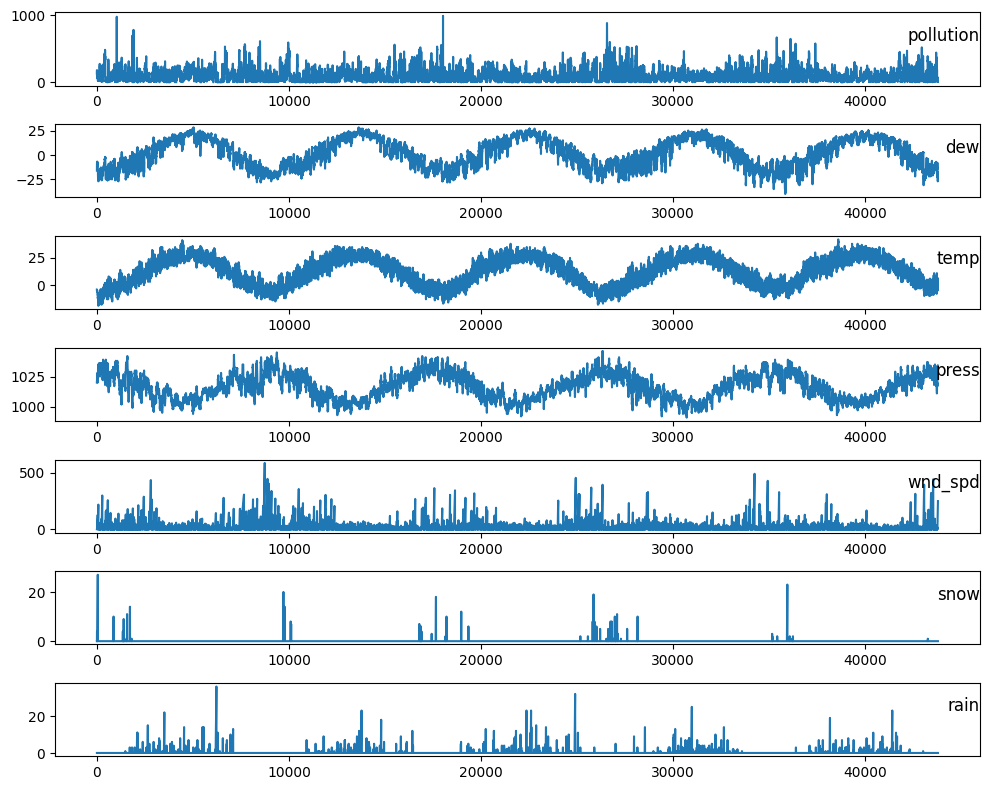

In [78]:
vals = data1.values

group_list = [0, 1, 2, 3, 5, 6, 7]

plt.figure(figsize=(10, 8))

i = 1
for group in group_list:
    plt.subplot(len(group_list), 1, i)
    plt.plot(vals[:, group])
    plt.title(data1.columns[group], y=0.5, loc='right')
    i += 1

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ

Từ các biểu đồ, có thể rút ra các nhận xét quan trọng:

1. **Pollution (PM2.5) biến động mạnh và không ổn định**
   - Có nhiều spike lớn → thể hiện các thời điểm ô nhiễm cao đột ngột
   - Đây là biến mục tiêu khó dự báo

2. **Temperature và Dew có tính mùa vụ rõ ràng**
   - Biến động theo chu kỳ lặp lại → phản ánh mùa trong năm
   - Đây là dấu hiệu strong seasonality

3. **Pressure biến động nhẹ và ổn định**
   - Ít noise hơn → có thể là biến hỗ trợ tốt cho modeling

4. **Wind speed có nhiều spike**
   - Gió mạnh có thể giúp giảm pollution
   - Đây là feature quan trọng

5. **Rain và Snow rất sparse**
   - Hầu hết giá trị = 0
   - chỉ xuất hiện tại một số thời điểm

Pollution không chỉ phụ thuộc vào thời gian mà còn phụ thuộc mạnh vào các biến khác như:
- temperature
- wind
- pressure

→ Đây chính là bản chất của multivariate time series

### Kết luận

- Multivariate time series chứa nhiều biến phụ thuộc thời gian
- Các biến có thể tương tác và ảnh hưởng lẫn nhau
- Cần preprocessing kỹ hơn
- Visualization phức tạp hơn

Đây là bước chuyển từ phân tích đơn giản → thực tế

## Recipe 1-4A. Time Series Components: Trends

### Bài toán

Mục tiêu của phần này là xác định một trong những thành phần quan trọng nhất của chuỗi thời gian, đó là **xu hướng (trend)**.

### Giải pháp

**Trend (xu hướng)** là sự chuyển động tổng thể của dữ liệu theo một hướng nhất định trong thời gian, có thể là:

- tăng dần (upward trend)
- giảm dần (downward trend)

Trend phản ánh sự thay đổi dài hạn của dữ liệu, không phải các dao động ngắn hạn.

### Dataset

Dataset được sử dụng là **Shampoo Sales Dataset**, bao gồm:

- doanh số bán dầu gội theo từng tháng
- dữ liệu kéo dài trong 3 năm

Đây là một ví dụ đơn giản nhưng rất rõ ràng để quan sát xu hướng tăng trưởng theo thời gian.

### Bước 4A-1. Import các thư viện cần thiết

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

### Bước 4A-2 và 4A-3. Đọc dữ liệu và xử lý cột thời gian

In [80]:
data = pd.read_csv('./data/shampoo-sales.csv')

# Cột Month trong dataset có dạng "1-01", "1-02",...
# cần chuyển thành datetime

data['Month'] = pd.to_datetime('190' + data['Month'], format='%Y-%m')

# đặt làm index
data.set_index('Month', inplace=True)

data.head()

,Sales
Month,
1901-01-01,266.0
1901-02-01,145.9
1901-03-01,183.1
1901-04-01,119.3
1901-05-01,180.3


### Phân tích code

- `pd.read_csv(...)`: đọc dữ liệu từ file CSV
- `'190' + data['Month']`:
  - dữ liệu gốc thiếu thế kỷ → cần thêm "190" vào phía trước
- `pd.to_datetime(..., format='%Y-%m')`:
  - chuyển sang dạng datetime
- `set_index('Month')`:
  - đặt thời gian làm index → chuẩn time series

Đây là cách thay thế cho `date_parser` trong tài liệu gốc

### Kiểm tra dữ liệu

In [81]:
print(data.info())
print()
print(data.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 36 entries, 1901-01-01 to 1903-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   36 non-null     float64
dtypes: float64(1)
memory usage: 576.0 bytes
None

            Sales
Month            
1901-01-01  266.0
1901-02-01  145.9
1901-03-01  183.1
1901-04-01  119.3
1901-05-01  180.3


### Phân tích output

- Dataset có dữ liệu theo tháng
- Cột `Month` đã trở thành datetime index
- Cột `Sales` là biến số chính

Dữ liệu đã ở dạng time series chuẩn để phân tích

### Bước 4A-4. Trực quan hóa chuỗi thời gian

<Figure size 1000x500 with 0 Axes>

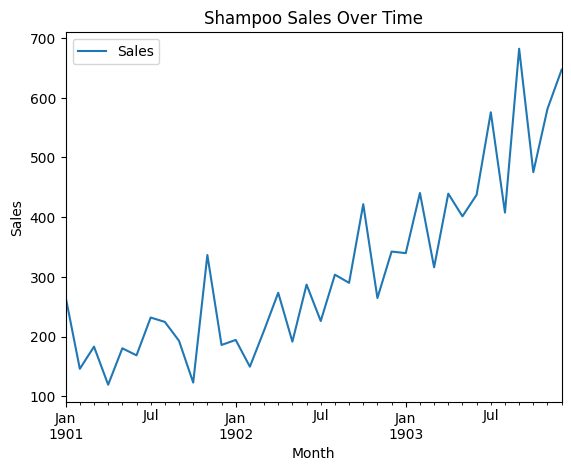

In [82]:
plt.figure(figsize=(10, 5))
data.plot()
plt.ylabel('Sales')
plt.title('Shampoo Sales Over Time')
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ có thể rút ra các nhận xét quan trọng:

1. **Xu hướng tăng rõ ràng (Strong upward trend)**  
   Doanh số tăng dần theo thời gian, đặc biệt rõ ở giai đoạn cuối → đây là đặc trưng của trend dài hạn.

2. **Không có tính mùa vụ rõ ràng**  
   Không xuất hiện các chu kỳ lặp lại đều đặn theo thời gian như dữ liệu AirPassengers.

3. **Biến động tăng theo thời gian (Increasing variance)**  
   Biên độ dao động lớn hơn ở giai đoạn sau → gợi ý rằng chuỗi có thể mang tính **multiplicative**.

4. **Dữ liệu không dừng (non-stationary)**  
   Do có xu hướng tăng rõ ràng → cần xử lý (differencing hoặc detrending) trước khi áp dụng các mô hình như ARIMA.

Đây là ví dụ điển hình của chuỗi thời gian có trend mạnh và không có seasonality rõ ràng.

### Kết luận

- Trend là thành phần quan trọng trong time series
- Dataset shampoo sales có xu hướng tăng rõ ràng
- Đây là ví dụ điển hình của chuỗi có trend nhưng không có seasonality


## Recipe 1-4B. Time Series Components: Seasonality

### Bài toán

Mục tiêu của phần này là xác định thành phần **tính mùa vụ (seasonality)** trong dữ liệu chuỗi thời gian.

### Giải pháp

**Seasonality (tính mùa vụ)** là sự lặp lại của một mẫu (pattern) trong dữ liệu theo chu kỳ thời gian nhất định.

Ví dụ:
- theo tháng (12 tháng)
- theo quý (4 quý)
- theo ngày trong năm (~365 ngày)

Seasonality phản ánh các yếu tố lặp lại theo chu kỳ như:
- thời tiết
- hành vi người dùng
- chu kỳ kinh tế

### Dataset

Dataset được sử dụng là **Daily Minimum Temperature (Melbourne)**:

- nhiệt độ tối thiểu theo ngày
- giai đoạn: 1981–1990
- dữ liệu theo ngày

Đây là dataset điển hình để quan sát **seasonality theo năm (365 ngày)**.

### Bước 4B-1. Import các thư viện cần thiết

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

### Bước 4B-2. Đọc dữ liệu

In [84]:
data = pd.read_csv(
    './data/daily-min-temperatures.csv',
    header=0,
    index_col=0,
    parse_dates=[0]
)

data.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


### Phân tích code

- `index_col=0`: dùng cột Date làm index
- `parse_dates=[0]`: chuyển cột Date sang datetime

👉 Đây là cách thay thế cho `squeeze=True` trong pandas cũ

### Bước 4B-3. Trực quan hóa chuỗi thời gian

<Figure size 1000x500 with 0 Axes>

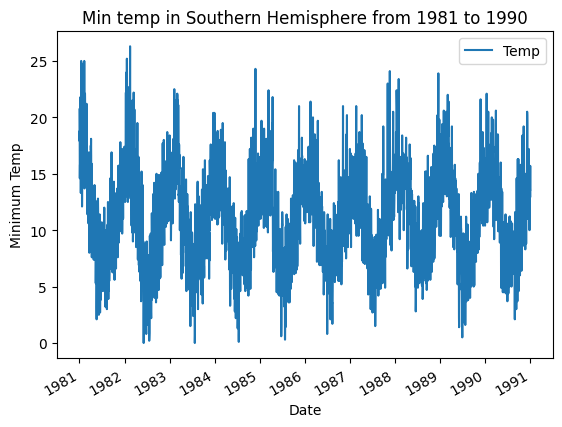

In [85]:
plt.figure(figsize=(10, 5))
data.plot()
plt.ylabel('Minimum Temp')
plt.title('Min temp in Southern Hemisphere from 1981 to 1990')
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ chuỗi thời gian có thể thấy:

1. **Tính mùa vụ rất rõ ràng (Strong seasonality)**  
   Nhiệt độ lặp lại theo chu kỳ hàng năm → pattern ổn định qua nhiều năm

2. **Không có xu hướng dài hạn (No trend)**  
   Dữ liệu dao động quanh một mức trung bình

3. **Biến động ngắn hạn (noise)**  
   Có nhiều dao động nhỏ theo ngày → phản ánh yếu tố thời tiết
   
 Đây là đặc trưng của một chuỗi seasonal điển hình

### Bước 4B-4. Phân tích theo tháng bằng boxplot

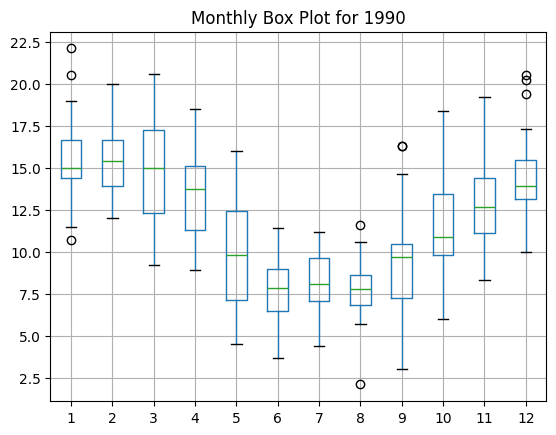

In [86]:
month_df = pd.DataFrame()

one_year_ser = data.loc['1990']
grouped_df = one_year_ser.groupby(pd.Grouper(freq='ME'))

month_df = pd.concat([pd.DataFrame(x[1].values) for x in grouped_df], axis=1)
month_df = pd.DataFrame(month_df)
month_df.columns = range(1, 13)

month_df.boxplot()
plt.title('Monthly Box Plot for 1990')
plt.show()

### Phân tích boxplot theo tháng

- Mỗi box thể hiện phân bố nhiệt độ của một tháng
- Có sự khác biệt rõ rệt giữa các tháng:

  - Tháng mùa hè (1–3, 12): nhiệt độ cao
  - Tháng mùa đông (6–8): nhiệt độ thấp

- Biên độ nhiệt thay đổi theo tháng
- Điều này xác nhận seasonality theo năm

→ Đây là seasonal pattern mạnh và ổn định

### Kết luận:

- Có seasonality theo tháng
- Dao động giữa mùa hè và mùa đông

### Bước 4B-5. Phân tích theo năm bằng boxplot

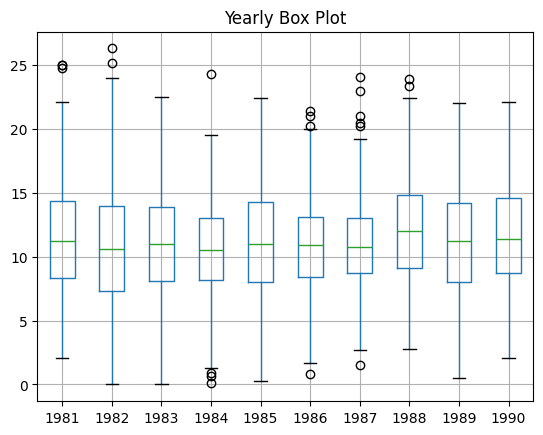

In [87]:
grouped_ser = data.groupby(pd.Grouper(freq='YE'))

year_df = pd.DataFrame()
for name, group in grouped_ser:
    year_df[name.year] = group['Temp'].values

year_df.boxplot()
plt.title('Yearly Box Plot')
plt.show()

### Phân tích boxplot theo năm

- Các boxplot giữa các năm khá giống nhau
- Không có sự thay đổi lớn về median và distribution

Điều này cho thấy:
- Không có trend dài hạn
- Seasonality ổn định qua các năm

→ Dữ liệu có tính lặp lại cao và không bị drift theo thời gian

### Kết luận

- Seasonality là pattern lặp lại theo thời gian
- Dataset nhiệt độ có seasonality rất rõ theo năm
- Không có trend dài hạn


## Recipe 1-4C. Time Series Components: Seasonality (cont’d.)

### Bài toán

Mục tiêu của phần này là tiếp tục phân tích **seasonality**, nhưng trong một dataset có cả:

- seasonality
- trend

Đây là trường hợp thực tế phổ biến hơn so với ví dụ trước.

### Giải pháp

Trong thực tế, dữ liệu chuỗi thời gian thường không chỉ có một thành phần duy nhất.

Dataset này sẽ giúp ta quan sát:
- seasonality (chu kỳ lặp lại)
- trend (xu hướng tăng)

Đây là dạng time series phức tạp hơn và gần với thực tế hơn.

### Dataset

Dataset được sử dụng là **Tractor Sales Dataset**, bao gồm:

- số lượng máy kéo bán ra theo tháng
- giai đoạn: 2003–2014

Đặc điểm:
- dữ liệu theo tháng
- có cả trend và seasonality

### Bước 4C-1. Import các thư viện cần thiết

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

### Bước 4C-2. Đọc dữ liệu

In [89]:
tractor_sales_data = pd.read_csv("./data/tractor_salesSales.csv")
tractor_sales_data.head(5)

,Month-Year,Number of Tractor Sold
0,3-Jan,141
1,3-Feb,157
2,3-Mar,185
3,3-Apr,199
4,3-May,203


### Bước 4C-3. Tạo chỉ mục thời gian

In [90]:
date_ser = pd.date_range(start='2003-01-01', freq='MS', periods=len(tractor_sales_data))

### Phân tích code

- `pd.date_range(...)` tạo chuỗi thời gian theo tháng
- `freq='MS'`: bắt đầu mỗi tháng
- `periods=len(...)`: số điểm bằng số dòng dữ liệu

Đây là cách tạo time index khi dataset không có sẵn cột datetime

### Bước 4C-4. Chuẩn hóa dữ liệu

In [91]:
tractor_sales_data.rename(columns={'Number of Tractor Sold': 'Tractor-Sales'}, inplace=True)
tractor_sales_data.set_index(date_ser, inplace=True)
tractor_sales_data = tractor_sales_data[['Tractor-Sales']]
tractor_sales_data.head(5)

,Tractor-Sales
2003-01-01,141
2003-02-01,157
2003-03-01,185
2003-04-01,199
2003-05-01,203


### Bước 4C-5. Trực quan hóa chuỗi thời gian

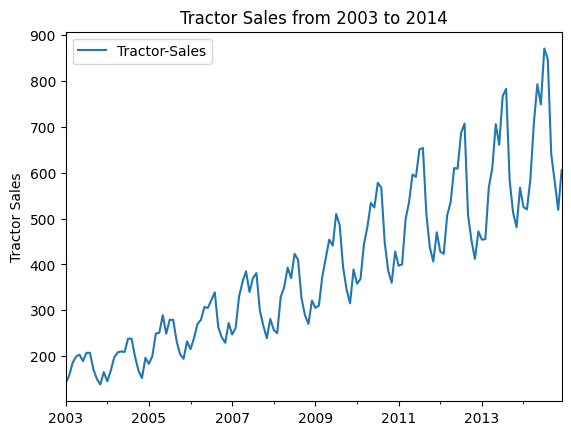

In [92]:
tractor_sales_data.plot()
plt.ylabel('Tractor Sales')
plt.title("Tractor Sales from 2003 to 2014")
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ có thể thấy:

1. **Xu hướng tăng rõ ràng (Trend)**  
   Doanh số máy kéo tăng dần theo thời gian

2. **Tính mùa vụ rõ ràng (Seasonality)**  
   Có các chu kỳ lặp lại theo năm

3. **Biên độ dao động tăng theo thời gian**  
   → dữ liệu có thể mang tính **multiplicative**

Đây là ví dụ điển hình của time series có cả:
- trend
- seasonality

### Bước 4C-6. Phân tích seasonality bằng boxplot theo tháng

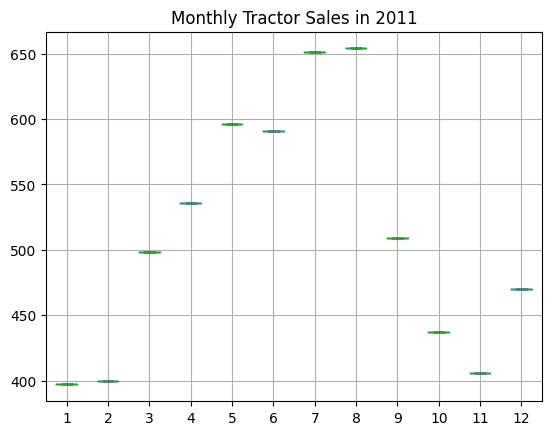

In [93]:
month_df = pd.DataFrame()
one_year_ser = tractor_sales_data.loc['2011']
grouped_ser = one_year_ser.groupby(pd.Grouper(freq='ME'))

month_df = pd.concat([pd.DataFrame(x[1].values) for x in grouped_ser], axis=1)
month_df = pd.DataFrame(month_df)
month_df.columns = range(1, 13)

month_df.boxplot()
plt.title('Monthly Tractor Sales in 2011')
plt.show()

### Phân tích boxplot theo tháng

- Trong phần này, dữ liệu của riêng năm 2011 được tách theo từng tháng
- Do mỗi tháng chỉ có một quan sát, boxplot không thể hiện đầy đủ phân bố như trường hợp có nhiều mẫu trong mỗi nhóm
- Tuy nhiên, biểu đồ vẫn cho thấy sự khác biệt rõ rệt giữa các tháng, đặc biệt là giai đoạn giữa năm có doanh số cao hơn

Điều này vẫn gợi ý sự tồn tại của seasonality, nhưng mức độ thể hiện chưa mạnh bằng boxplot tháng ở ví dụ nhiệt độ hằng ngày.

### Kết luận

- Dataset tractor sales có cả trend và seasonality
- Đây là dạng time series phổ biến trong thực tế
- cần sử dụng các mô hình phù hợp như:
  - SARIMA
  - Holt-Winters
  - LSTM



## Recipe 1-5A. Time Series Decomposition: Additive Model

### Bài toán

Mục tiêu của phần này là tìm hiểu cách **phân rã chuỗi thời gian (time series decomposition)** bằng **mô hình cộng (additive model)**.

### Giải pháp

Mô hình cộng (**additive model**) giả định rằng chuỗi thời gian được tạo thành từ tổng của các thành phần:

\[
Y_t = T_t + S_t + R_t
\]

Trong đó:

- \(T_t\): xu hướng (trend)
- \(S_t\): mùa vụ (seasonality)
- \(R_t\): nhiễu hoặc phần dư (residual / random)

Mô hình cộng phù hợp khi:

- xu hướng tăng hoặc giảm tương đối tuyến tính
- biên độ mùa vụ gần như không đổi theo thời gian
- mức dao động theo chu kỳ không tăng mạnh theo mức độ của chuỗi

### Dataset

Dataset được sử dụng là **Retail Turnover**, bao gồm:

- doanh thu bán lẻ theo quý
- giai đoạn từ năm 1982 đến 1992

Đây là bộ dữ liệu phù hợp để minh họa decomposition vì:
- có xu hướng tăng
- có tính mùa vụ theo quý
- seasonality tương đối ổn định

### Bước 5A-1. Import các thư viện cần thiết

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

### Phân tích code

- `pandas`: đọc và xử lý dữ liệu
- `matplotlib`: trực quan hóa dữ liệu
- `seasonal_decompose` trong `statsmodels`: dùng để phân rã chuỗi thời gian thành các thành phần
- `statsmodels.api as sm`: hỗ trợ gọi hàm decomposition theo cách quen thuộc trong sách

### Bước 5A-2. Đọc và xử lý dữ liệu retail turnover

In [95]:
turn_over_data = pd.read_csv('./data/RetailTurnover.csv')

date_range = pd.date_range(
    start='1/7/1982',
    end='31/3/1992',
    freq='QE'
)

turn_over_data['TimeIndex'] = pd.DataFrame(date_range, columns=['Quarter'])

turn_over_data.head()

,Year,Quarter,Turnover,TimeIndex
0,1982,Q3,13423.2,1982-03-31
1,1982,Q4,13128.8,1982-06-30
2,1983,Q1,15398.8,1982-09-30
3,1983,Q2,12964.2,1982-12-31
4,1983,Q3,13133.5,1983-03-31


### Phân tích code

- `pd.read_csv(...)`: đọc dữ liệu doanh thu bán lẻ
- `pd.date_range(...)`: tạo chuỗi thời gian theo quý
- `freq='QE'`: dữ liệu được biểu diễn theo quý
- thêm cột `TimeIndex` để dùng làm trục thời gian khi trực quan hóa

Cách làm này bám sát tài liệu gốc: dữ liệu thời gian được tạo thủ công bằng `date_range` thay vì lấy trực tiếp từ cột `Year` và `Quarter`.

### Bước 5A-3. Trực quan hóa chuỗi thời gian

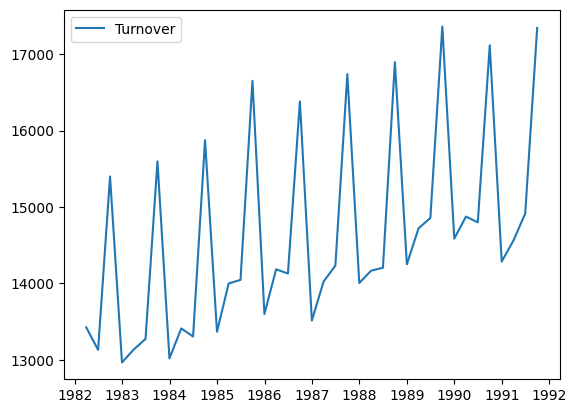

In [96]:
plt.plot(turn_over_data.TimeIndex, turn_over_data.Turnover, label='Turnover')
plt.legend(loc='best')
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ chuỗi thời gian có thể thấy:

1. **Xu hướng tăng dần theo thời gian**  
   Doanh thu bán lẻ nhìn chung tăng lên qua các năm.

2. **Mùa vụ theo quý xuất hiện khá rõ**  
   Dữ liệu có các dao động lặp lại đều đặn theo từng năm, phản ánh seasonal pattern theo chu kỳ 4 quý.

3. **Biên độ mùa vụ tương đối ổn định**  
   Mức dao động giữa các quý không thay đổi quá mạnh theo thời gian.

Vì vậy, bộ dữ liệu này phù hợp với **mô hình cộng (additive model)** hơn là mô hình nhân ở bước minh họa ban đầu.

### Liên hệ lý thuyết trước khi decomposition

Trước khi phân rã chuỗi thời gian, ta cần quan sát xem dữ liệu có phù hợp với additive model hay không.

Trong additive model:

- trend và seasonality kết hợp theo phép cộng
- biên độ mùa vụ gần như cố định qua thời gian

Quan sát từ biểu đồ retail turnover cho thấy:
- trend tăng tương đối đều
- seasonality lặp lại ổn định theo quý

Do đó, việc áp dụng decomposition theo mô hình cộng là hợp lý.

### Bước 5A-4. Phân rã chuỗi thời gian

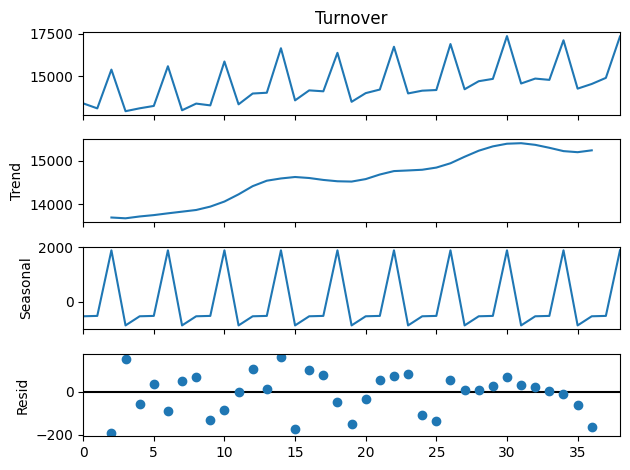

<Figure size 1000x500 with 0 Axes>

In [97]:
decomp_turn_over = sm.tsa.seasonal_decompose(
    turn_over_data.Turnover,
    model="additive",
    period=4
)

decomp_turn_over.plot()
plt.figure(figsize=(10, 5))
plt.show()

### Phân tích code

- `seasonal_decompose(...)`: phân rã chuỗi thời gian thành các thành phần:
  - observed
  - trend
  - seasonal
  - resid

- `model="additive"`:
  - chỉ định sử dụng mô hình cộng

- `period=4`:
  - chu kỳ mùa vụ là 4, tương ứng với 4 quý trong một năm

### Ghi chú về phiên bản thư viện

Trong tài liệu gốc, tác giả dùng:

```python
freq=4
```
Tuy nhiên, ở phiên bản statsmodels mới, tham số phù hợp là:
```python
period=4
```
Do đó, notebook này chỉ cập nhật đúng điểm đó để tương thích với phiên bản hiện tại, còn ý tưởng lý thuyết vẫn giữ nguyên như sách.

### Phân tích output decomposition

Biểu đồ decomposition gồm 4 thành phần:

1. **Observed (chuỗi gốc)**  
   Thể hiện dữ liệu doanh thu ban đầu theo thời gian.

2. **Trend (xu hướng)**  
   - Xu hướng tăng dần rõ rệt  
   - Tăng tương đối mượt và tuyến tính

3. **Seasonal (mùa vụ)**  
   - Lặp lại theo chu kỳ 4 quý  
   - Biên độ gần như không đổi qua thời gian  
   → phù hợp với giả định của additive model

4. **Residual (phần dư)**  
   - Dao động nhỏ quanh 0  
   - Không có cấu trúc rõ ràng  

👉 Điều này cho thấy:
- mô hình additive phù hợp với dữ liệu
- phần lớn biến động đã được giải thích bởi trend và seasonality

### Ý nghĩa của decomposition

Phân rã chuỗi thời gian giúp ta:

- hiểu rõ cấu trúc dữ liệu
- tách riêng từng thành phần để phân tích
- kiểm tra xem dữ liệu phù hợp với additive hay multiplicative model
- hỗ trợ lựa chọn mô hình dự báo phù hợp hơn

Đây là bước rất quan trọng trước khi đi vào forecasting.

### Bước 5A-5. Tách riêng từng thành phần

In [98]:
trend = decomp_turn_over.trend
seasonal = decomp_turn_over.seasonal
residual = decomp_turn_over.resid

### Phân tích code

Sau khi decomposition, ta có thể truy xuất riêng từng thành phần:

- `trend`: chuỗi xu hướng
- `seasonal`: chuỗi mùa vụ
- `residual`: chuỗi phần dư

Điều này hữu ích khi:
- muốn phân tích từng thành phần độc lập
- muốn vẽ riêng từng phần
- muốn dùng residual để kiểm tra phần thông tin chưa được giải thích

### Kiểm tra nhanh các thành phần

In [99]:
print(trend.head())
print()
print(seasonal.head())
print()
print(residual.head())

0           NaN
1           NaN
2    13692.5375
3    13674.1875
4    13716.7375
Name: trend, dtype: float64

0    -524.613498
1    -510.713672
2    1894.960113
3    -859.632943
4    -524.613498
Name: seasonal, dtype: float64

0           NaN
1           NaN
2   -188.697613
3    149.645443
4    -58.624002
Name: resid, dtype: float64


### Phân tích giá trị cụ thể của các thành phần

- `trend`:
  - có giá trị NaN ở đầu chuỗi  
  → do cần cửa sổ dữ liệu để tính trung bình trượt

- `seasonal`:
  - có giá trị lặp lại theo chu kỳ 4 quý  
  - ví dụ: quý cao có giá trị dương lớn (~1900), quý thấp có giá trị âm

- `residual`:
  - dao động quanh 0  
  - biên độ nhỏ hơn nhiều so với chuỗi gốc

Điều này xác nhận decomposition đã tách được:
- pattern chính (trend + seasonality)
- phần nhiễu còn lại

### Kết luận

Trong recipe này, ta đã:

- đọc dữ liệu retail turnover
- trực quan hóa chuỗi thời gian
- nhận diện trend và seasonality
- phân rã chuỗi bằng **additive model**
- tách riêng trend, seasonal và residual

Kết quả cho thấy dữ liệu retail turnover:

- có xu hướng tăng dần
- có mùa vụ theo quý
- phù hợp với mô hình cộng do biên độ mùa vụ khá ổn định

Đây là ví dụ điển hình về decomposition theo additive model.

## Recipe 1-5B. Time Series Decomposition: Multiplicative Model

### Bài toán

Mục tiêu của phần này là tìm hiểu cách **phân rã chuỗi thời gian** bằng **mô hình nhân (multiplicative model)**.

### Giải pháp

Mô hình nhân (**multiplicative model**) giả định rằng:

\[
Y_t = T_t x S_t x R_t
\]

Trong đó:

- \(T_t\): xu hướng (trend)
- \(S_t\): mùa vụ (seasonality)
- \(R_t\): nhiễu (residual)

Đặc điểm của multiplicative model:

- dữ liệu mang tính **phi tuyến (non-linear)**
- biên độ mùa vụ **tăng hoặc giảm theo thời gian**
- dao động lớn hơn khi giá trị chuỗi tăng

Đây là điểm khác biệt chính so với additive model.

### Dataset

Dataset được sử dụng là **AirPax**, bao gồm:

- số lượng hành khách hàng không theo tháng
- giai đoạn từ 1949 đến 1960

Đặc điểm:

- có trend tăng mạnh
- có seasonality rõ ràng theo năm
- biên độ mùa vụ tăng theo thời gian

Đây là dataset điển hình cho multiplicative model.

### Bước 5B-1. Import các thư viện cần thiết

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

### Bước 5B-2. Đọc dữ liệu Air Passengers

In [101]:
air_passengers_data = pd.read_csv('./data/AirPax.csv')
air_passengers_data.head()

,Year,Month,Passenger
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


### Bước 5B-3. Tạo chỉ mục thời gian

In [102]:
date_range = pd.date_range(
    start='1/1/1949',
    end='31/12/1960',
    freq='ME'
)

air_passengers_data['TimeIndex'] = pd.DataFrame(date_range, columns=['Month'])

air_passengers_data.head()

,Year,Month,Passenger,TimeIndex
0,1949,Jan,112,1949-01-31
1,1949,Feb,118,1949-02-28
2,1949,Mar,132,1949-03-31
3,1949,Apr,129,1949-04-30
4,1949,May,121,1949-05-31


### Phân tích code

- `pd.date_range(...)`: tạo chuỗi thời gian theo tháng
- `freq='ME'`: dữ liệu theo tháng (month end)
- thêm cột `TimeIndex` để làm trục thời gian


### Bước 5B-4. Trực quan hóa chuỗi thời gian

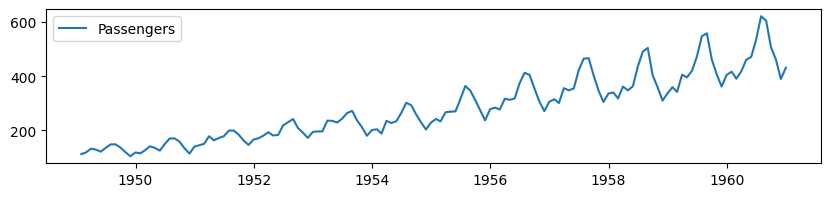

In [103]:
plt.figure(figsize=(10, 2))
plt.plot(air_passengers_data.TimeIndex, air_passengers_data.Passenger, label='Passengers')
plt.legend(loc='best')
plt.show()

### Nhận xét biểu đồ

Từ biểu đồ có thể thấy:

1. **Xu hướng tăng mạnh (Trend)**  
   Số lượng hành khách tăng nhanh theo thời gian

2. **Tính mùa vụ rõ ràng (Seasonality)**  
   Có các chu kỳ lặp lại theo từng năm

3. **Biên độ mùa vụ tăng theo thời gian**  
   - các đỉnh sau cao hơn nhiều so với đỉnh trước  
   - dao động lớn hơn khi giá trị tăng  

Đây là đặc trưng của **multiplicative time series**

### Bước 5B-5. Phân rã chuỗi thời gian

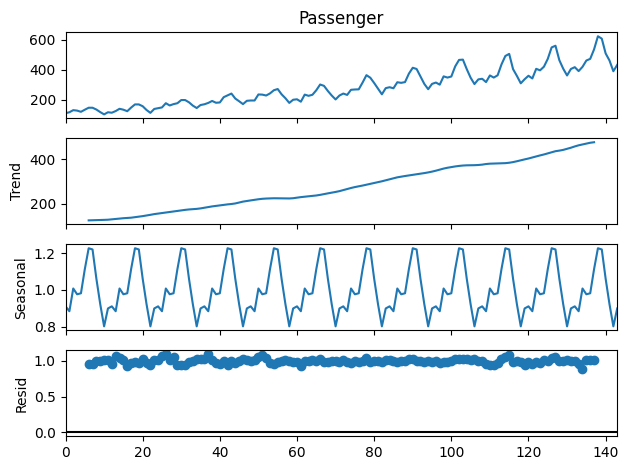

In [104]:
decomp_air_passengers_data = sm.tsa.seasonal_decompose(
    air_passengers_data.Passenger,
    model="multiplicative",
    period=12
)

decomp_air_passengers_data.plot()
plt.show()

### Phân tích code

- `model="multiplicative"`:
  - sử dụng mô hình nhân

- `period=12`:
  - chu kỳ mùa vụ là 12 tháng

Trong tài liệu gốc dùng `freq=12`, nhưng trong version mới cần dùng `period=12`.

### Phân tích output decomposition

Biểu đồ gồm 4 phần:

1. **Observed**
   - chuỗi gốc

2. **Trend**
   - tăng mạnh theo thời gian

3. **Seasonal**
   - pattern lặp lại theo 12 tháng
   - giá trị seasonal dao động quanh 1 (do là multiplicative)

4. **Residual**
   - dao động nhỏ quanh 1

Điểm quan trọng:
- seasonal không còn là cộng/trừ như additive
- mà là **tỷ lệ (ratio)** so với trend

### Bước 5B-6. Lấy riêng thành phần mùa vụ

In [105]:
Seasonal_comp = decomp_air_passengers_data.seasonal
Seasonal_comp.head(4)

0    0.910230
1    0.883625
2    1.007366
3    0.975906
Name: seasonal, dtype: float64

### Phân tích output

Ví dụ:

- giá trị seasonal ≈ 0.9 → thấp hơn trung bình
- giá trị seasonal ≈ 1.1 → cao hơn trung bình

Trong multiplicative model:
- seasonal thể hiện **tỷ lệ thay đổi**
- không phải giá trị cộng/trừ như additive

### So sánh Additive và Multiplicative Model

| Đặc điểm | Additive | Multiplicative |
|----------|---------|----------------|
| Công thức | Y = T + S + R | Y = T × S × R |
| Tính chất | tuyến tính | phi tuyến |
| Seasonality | biên độ không đổi | biên độ thay đổi |
| Dữ liệu phù hợp | dao động ổn định | dao động tăng theo thời gian |

Rule quan trọng:

- nếu biên độ seasonal **không đổi** → dùng additive  
- nếu biên độ seasonal **tăng theo thời gian** → dùng multiplicative

### Kết luận

- Multiplicative model phù hợp với dữ liệu có:
  - trend mạnh
  - seasonality tăng theo thời gian

- Dataset AirPax là ví dụ điển hình của multiplicative time series

Decomposition giúp:
- hiểu cấu trúc dữ liệu
- chọn đúng mô hình forecasting

## Recipe 1-6. Visualization of Seasonality

### Bài toán

Mục tiêu của phần này là tìm hiểu cách **trực quan hóa thành phần seasonality** trong chuỗi thời gian.

### Giải pháp

Ngoài decomposition, seasonality có thể được phát hiện thông qua:

- pivot table
- line chart theo nhóm (quarter/month)
- boxplot theo nhóm

Các phương pháp này giúp:
- so sánh giữa các chu kỳ
- phát hiện pattern lặp lại

### Dataset

Dataset sử dụng là **Retail Turnover**, gồm:

- doanh thu bán lẻ theo quý
- giai đoạn 1982–1992

Đây là dataset có seasonality theo quý.

### Bước 6-1. Import các thư viện cần thiết

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

### Bước 6-2. Đọc dữ liệu

In [107]:
turn_over_data = pd.read_csv('./data/RetailTurnover.csv')
turn_over_data.head()

,Year,Quarter,Turnover
0,1982,Q3,13423.2
1,1982,Q4,13128.8
2,1983,Q1,15398.8
3,1983,Q2,12964.2
4,1983,Q3,13133.5


### Bước 6-3. Xử lý dữ liệu

In [108]:
date_range = pd.date_range(
    start='1/7/1982',
    end='31/3/1992',
    freq='QE'
)

turn_over_data['TimeIndex'] = pd.DataFrame(date_range, columns=['Quarter'])

### Phân tích code

- `date_range(...)`: tạo chuỗi thời gian theo quý
- `freq='QE'`: dữ liệu theo quý
- thêm `TimeIndex` để dùng khi cần


### Bước 6-4. Pivot bảng dữ liệu

In [109]:
quarterly_turn_over_data = pd.pivot_table(
    turn_over_data,
    values="Turnover",
    columns="Quarter",
    index="Year"
)

quarterly_turn_over_data

Quarter,Q1,Q2,Q3,Q4
Year,,,,
1982,NaN,NaN,13423.2,13128.8
1983,15398.8,12964.2,13133.5,13271.7
1984,15596.3,13018.0,13409.3,13304.2
1985,15873.9,13366.5,13998.6,14045.1
1986,16650.3,13598.4,14183.2,14128.5
1987,16380.7,13512.8,14022.1,14231.8
1988,16737.0,14004.5,14165.5,14203.9
1989,16895.1,14248.2,14719.5,14855.8
1990,17361.6,14585.2,14873.5,14798.4


### Phân tích pivot table

- Rows (index): Year
- Columns: Quarter (Q1, Q2, Q3, Q4)
- Values: Turnover

Ý nghĩa:

- mỗi dòng là một năm
- mỗi cột là một quý
- dễ so sánh các quý giữa các năm

Đây là cách trực quan rất mạnh để nhìn seasonality

### Bước 6-5. Vẽ biểu đồ đường theo quý

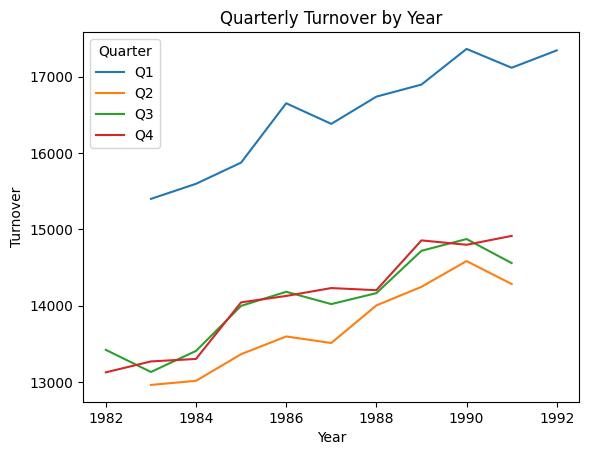

In [110]:
quarterly_turn_over_data.plot()
plt.title('Quarterly Turnover by Year')
plt.ylabel('Turnover')
plt.show()

### Nhận xét biểu đồ line

- Mỗi đường biểu diễn một quý (Q1, Q2, Q3, Q4)
- Các đường có xu hướng tăng theo thời gian (trend)

Quan trọng:

- Q1 luôn cao hơn các quý khác
- Q2 thường thấp nhất

→ Điều này cho thấy pattern lặp lại theo năm

Đây chính là seasonality

### Bước 6-6. Vẽ boxplot theo quý

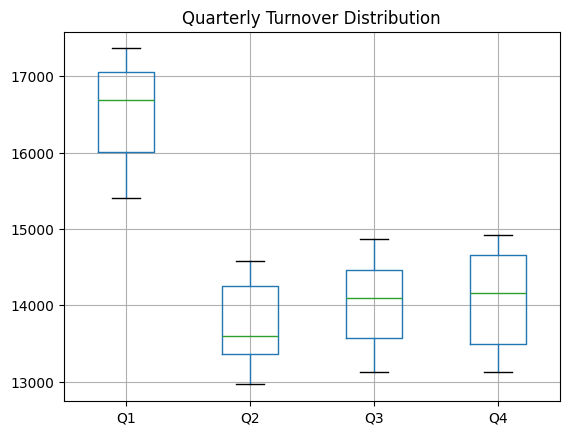

In [111]:
quarterly_turn_over_data.boxplot()
plt.title('Quarterly Turnover Distribution')
plt.show()

### Phân tích boxplot

- Mỗi box đại diện cho phân bố turnover của một quý

Quan sát:

- Q1 có median cao nhất
- Q2 có median thấp nhất
- Q3 và Q4 nằm giữa

Điều này xác nhận:

- doanh thu có pattern theo quý
- Q1 luôn là quý mạnh
- Q2 là quý yếu

→ Seasonality theo quý rất rõ ràng

### Kết luận

- Seasonality có thể được quan sát rõ thông qua pivot + plot
- Dataset retail turnover có:
  - Q1 cao nhất
  - Q2 thấp nhất
- Pattern này lặp lại theo năm

Đây là bằng chứng rõ ràng của seasonality